# recon/ demo

Every reconstruction in `recon/` on one real dataset, `20260915ball/2_6x_2.4mm`
(ball phantom, 2.4 mm, R = 6, 60 frames).

All the iterative methods solve

$$\hat x = \arg\min_x \tfrac12 \|A x - y\|_2^2 + g(x)$$

* **A**, the encoding operator (`recon/mri_operator.py`), comes in three versions:
  * `SENSE`: coil sensitivities, then FFT, then keep the sampled k-space points
  * `SENSE_B0`: also models phase accrual from the B0 field map over the echo train
  * `SENSE_B0_R2star`: also models magnitude decay from an R2* map
* **g**, the regularizer (`recon/regularizers.py`), picks the solver (`recon/solvers.py`):
  * none: conjugate gradient
  * multi-scale low-rank: POGM
  * L1-wavelet + TV: primal-dual (FBPD)

`recon/sense.py` puts these together, and `recon/rss.py` is the non-iterative
root-sum-of-squares baseline. Every cell here runs a function directly and
shows the result. The command-line equivalents, which also save to disk, are
listed at the end.

Run in `.venv-recon`. Iteration counts and frame counts are kept small but the
whole notebook still takes about 12 minutes on one RTX A6000. Most of that is
power iteration for the B0 operators' spectral norms.

In [1]:
import sys
import time
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import torch

REPO = Path.cwd().parent if Path.cwd().name == "recon" else Path.cwd()
sys.path.insert(0, str(REPO))

from preprocessing.config import load_config, load_seq_params, set_seq_paths  # noqa: E402
from preprocessing.r2star_map import estimate_r2star_map_epi_grid  # noqa: E402
from recon.mri_operator import build_sense, build_sense_b0, build_sense_b0_r2star  # noqa: E402
from recon.rss import run_rss  # noqa: E402
from recon.sense import run_sense  # noqa: E402
from recon.utils import (  # noqa: E402
    load_and_gather_ksp,
    load_array,
    load_echo_times,
    load_normalized_smaps,
    load_omega,
    nominal_te_s,
)

DATDIR = "/StorageRAID/rexfung/20260915ball"
SEQ = "2_6x_2.4mm"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

RECON_DIR = f"{DATDIR}/recon"
FN_KSP = f"{RECON_DIR}/{SEQ}_epi_zf.h5"      # zero-filled k-space from preprocessing/
FN_SMAPS = f"{RECON_DIR}/smaps_{SEQ}_sigpy.h5"  # ESPIRiT coil sensitivities
FN_B0 = f"{RECON_DIR}/{SEQ}_b0map.h5"          # B0 field map (Hz), preprocessing/run_b0map.py

In [2]:
def show(images: dict, frame: int = 0, title: str = ""):
    """Central axial / coronal / sagittal magnitude slices of one frame, one row per image."""
    fig, axes = plt.subplots(len(images), 3, figsize=(9, 3 * len(images)), squeeze=False)
    for row, (name, img) in zip(axes, images.items()):
        img = img.detach().cpu().numpy() if torch.is_tensor(img) else np.asarray(img)
        vol = np.abs(img[..., frame] if img.ndim == 4 else img)
        vmax = np.percentile(vol, 99.5)
        cx, cy, cz = (n // 2 for n in vol.shape)
        for ax, sl in zip(row, [vol[:, :, cz], vol[:, cy, :], vol[cx, :, :]]):
            ax.imshow(sl.T, cmap="gray", origin="lower", vmin=0, vmax=vmax)
            ax.set_xticks([])
            ax.set_yticks([])
        row[0].set_ylabel(name)
    for ax, view in zip(axes[0], ["axial", "coronal", "sagittal"]):
        ax.set_title(view)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def free_gpu():
    if DEVICE == "cuda":
        torch.cuda.empty_cache()

## 1. The data

`ksp_epi_zf` is `(Nx, Ny, Nz, Ncoils, Nframes)`, zero wherever a (ky, kz)
location wasn't sampled. `omegas` is the sampling mask, `(Ny, Nz, Nframes)`,
which is the same for every kx. `echo_times` gives each sample's time since
excitation, which the B0/R2* operators need.

echo_times   (90, 60, 60) float64
ksp_epi_zf   (90, 90, 60, 14, 60) complex64
omegas       (90, 60, 60) bool


R = 6.00


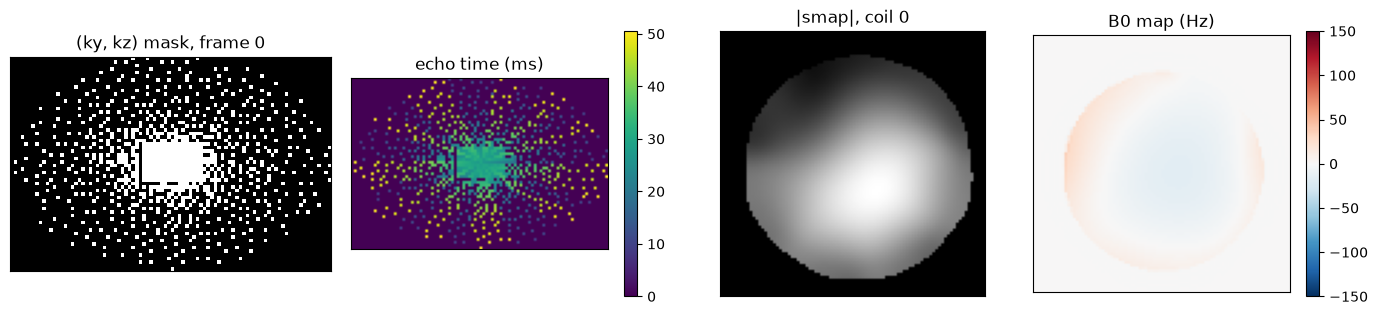

In [3]:
with h5py.File(FN_KSP) as f:
    for k in f:
        print(f"{k:12s} {f[k].shape} {f[k].dtype}")
    Nx, Ny, Nz, Nc, Nt = f["ksp_epi_zf"].shape

omega = load_omega(FN_KSP, Nx, Ny, Nz, Nt, DEVICE)  # (Nx, Ny, Nz, Nt) bool
echo_times = load_echo_times(FN_KSP, DEVICE)       # (Ny, Nz, Nt) seconds
smaps, smaps_chw = load_normalized_smaps(FN_SMAPS, DEVICE)  # (Nx,Ny,Nz,Nc) and (Nc,Nx,Ny,Nz)
b0map_hz = torch.from_numpy(load_array(FN_B0, "b0map_hz")).to(DEVICE)
print(f"R = {Nx * Ny * Nz / omega[..., 0].sum().item():.2f}")

fig, ax = plt.subplots(1, 4, figsize=(14, 3.2))
ax[0].imshow(omega[0, :, :, 0].cpu().T, origin="lower", cmap="gray")
ax[0].set_title("(ky, kz) mask, frame 0")
im = ax[1].imshow(1000 * echo_times[:, :, 0].cpu().T, origin="lower")
ax[1].set_title("echo time (ms)")
plt.colorbar(im, ax=ax[1])
ax[2].imshow(smaps[:, :, Nz // 2, 0].abs().cpu().T, origin="lower", cmap="gray")
ax[2].set_title("|smap|, coil 0")
b0_slice = b0map_hz[:, :, Nz // 2].cpu().T
im = ax[3].imshow(b0_slice, origin="lower", cmap="RdBu_r", vmin=-150, vmax=150)
ax[3].set_title("B0 map (Hz)")
plt.colorbar(im, ax=ax[3])
for a in ax:
    a.set_xticks([])
    a.set_yticks([])
plt.tight_layout()
plt.show()

The R2* map comes from the dual-echo deGRE data (`<seq>_gre.h5`). R2* decay is
measured relative to the nominal TE, the time of the echo at the center of the
echo train.

In [4]:
paths = set_seq_paths(load_config(datdir=DATDIR, seqnames=[SEQ]), SEQ)
sp = load_seq_params(paths)
T_REF = nominal_te_s(paths.scan_info, sp.ETL)
r2star = torch.from_numpy(
    estimate_r2star_map_epi_grid(DATDIR, SEQ, sp.fov_degre, sp.fov, (Nx, Ny, Nz))
).to(DEVICE)
print(f"nominal TE = {1000 * T_REF:.2f} ms, R2* in [{r2star.min():.1f}, {r2star.max():.1f}] 1/s")

nominal TE = 29.65 ms, R2* in [0.0, 130.1] 1/s


## 2. The three encoding operators

Each builder returns a mirtorch `BlockDiagonal` with one operator per frame, mapping
`(Nx, Ny, Nz, Nt)` images to `(K, Ncoils, Nt)` k-space. The output holds only the
K sampled points, not a zero-filled grid. Here they're built for frame 0 only.
`L` is the number of time segments used to approximate the B0 phase accrual over
the ~70 ms echo train (32 is the production value).

A quick check of each: the adjoint applied to the data, $A^H y$, is a
matched-filter image, and the adjoint dot-product test $\langle Ax, y\rangle =
\langle x, A^H y\rangle$ confirms the adjoint is exact.

  build_sense_b0_r2star: R2* decay-time product = 5.3424 vs Δf's bandwidth-time product = 9.21 (should be much smaller -- this is what justifies reusing Δf-only-tuned b_by_echo/tl for the complex field; see module docstring).


SENSE            SENSE            adjoint test rel. error 2.1e-07


SENSE_B0         SENSE_B0         adjoint test rel. error 2.5e-07


SENSE_B0_R2star  SENSE_B0_R2star  adjoint test rel. error 2.5e-07


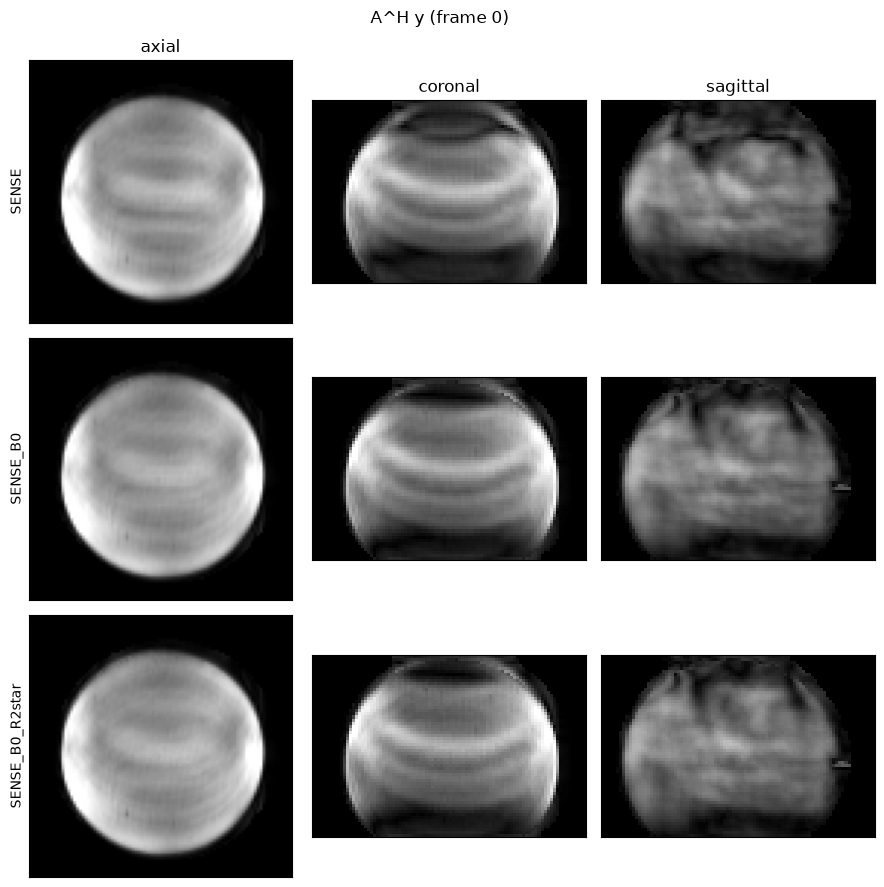

In [5]:
om0, et0 = omega[..., :1], echo_times[..., :1]
ops = {
    "SENSE": build_sense(smaps_chw, om0),
    "SENSE_B0": build_sense_b0(smaps_chw, om0, b0map_hz, et0, L=32),
    "SENSE_B0_R2star": build_sense_b0_r2star(smaps_chw, om0, b0map_hz, et0, r2star, T_REF, L=32),
}
y = load_and_gather_ksp(FN_KSP, ops["SENSE"], DEVICE, frames=[0])  # (K, Nc, 1)

adjoints = {}
for name, A in ops.items():
    x = torch.randn(Nx, Ny, Nz, 1, dtype=torch.complex64, device=DEVICE)
    w = torch.randn(*A.size_out, dtype=torch.complex64, device=DEVICE)
    lhs = torch.vdot(A.apply(x).flatten(), w.flatten())
    rhs = torch.vdot(x.flatten(), A.adjoint(w).flatten())
    rel = (abs(lhs - rhs) / abs(lhs)).item()
    print(f"{name:16s} {type(A.A[0]).__name__:16s} adjoint test rel. error {rel:.1e}")
    adjoints[name] = A.adjoint(y)
show(adjoints, title="A^H y (frame 0)")
del ops, adjoints
free_gpu()

## 3. Root-sum-of-squares (`recon/rss.py`)

Zero-filled inverse FFT per coil, then $\sqrt{\sum_c |x_c|^2}$. It uses no
sensitivity maps and no B0 model, so undersampling aliasing is left in. Frames
are batched on the GPU.

  frames 1-24/60 done


  frames 25-48/60 done


  frames 49-60/60 done
(90, 90, 60, 60), 10.5 s for all 60 frames


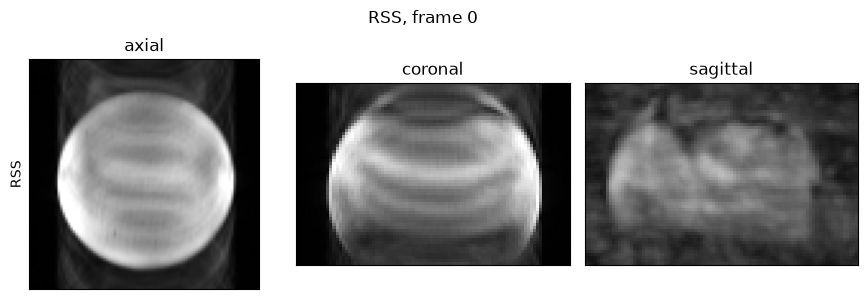

In [6]:
t0 = time.time()
img_rss = run_rss(FN_KSP, device=DEVICE)
print(f"{img_rss.shape}, {time.time() - t0:.1f} s for all {Nt} frames")
show({"RSS": img_rss}, title="RSS, frame 0")

## 4. Iterative SENSE (`recon/sense.py`)

`run_sense` is the single entry point: pass `reg`, and optionally `fn_b0map`
(→ `SENSE_B0`), plus `r2star_map` / `t_ref_s` (→ `SENSE_B0_R2star`). It returns
a `ReconResult` holding `X_recon` `(Nx, Ny, Nz, Nt)`, the per-iteration cost
trace, and the settings used. The helper below runs one regularizer with each
of the three operators.

In [7]:
def recon_three_ways(reg, **kwargs):
    """Run run_sense with SENSE, SENSE_B0 and SENSE_B0_R2star; return {label: ReconResult}."""
    variants = {
        "SENSE": {},
        "SENSE_B0": dict(fn_b0map=FN_B0),
        "SENSE_B0_R2star": dict(fn_b0map=FN_B0, r2star_map=r2star, t_ref_s=T_REF),
    }
    out = {}
    for label, v in variants.items():
        t0 = time.time()
        out[label] = run_sense(
            fn_ksp=FN_KSP, fn_smaps=FN_SMAPS, reg=reg, device=DEVICE, **v, **kwargs
        )
        print(f"==> {label}: {time.time() - t0:.1f} s")
        free_gpu()
    return out

### 4a. No regularizer: CG-SENSE

`reg="none"` solves the normal equations $A^H A x = A^H y$ with conjugate
gradient. `dc_costs` holds the relative residual per iteration. This demo runs
2 frames for 20 iterations; the CLI default is 150.

Loading sensitivity maps...
  Sensitivity maps: (90, 90, 60, 14)
Acceleration factor R ~ 6.00
Building encoding operator...
Loading k-space (gathered per frame, never materializing the dense array)...


  VRAM free after loading gathered k-space: 48.88 / 50.90 GB

Running CG-SENSE (20 iterations max, tol=1e-06)...
Done in 0.2 s (20 iterations, final relative residual 2.585e-03).
==> SENSE: 0.5 s
Loading sensitivity maps...


  Sensitivity maps: (90, 90, 60, 14)
Acceleration factor R ~ 6.00
Building encoding operator...
  Loading B0 field map from /StorageRAID/rexfung/20260915ball/recon/2_6x_2.4mm_b0map.h5 (L=32, nbins=128)...
Loading k-space (gathered per frame, never materializing the dense array)...


  VRAM free after loading gathered k-space: 48.88 / 50.90 GB

Running CG-SENSE (20 iterations max, tol=1e-06)...


Done in 5.8 s (20 iterations, final relative residual 6.560e-03).
==> SENSE_B0: 6.1 s
Loading sensitivity maps...
  Sensitivity maps: (90, 90, 60, 14)
Acceleration factor R ~ 6.00
Building encoding operator...
  Loading B0 field map from /StorageRAID/rexfung/20260915ball/recon/2_6x_2.4mm_b0map.h5 (L=32, nbins=128)...
  R2* correction enabled (t_ref_s=29.651 ms)...
  build_sense_b0_r2star: R2* decay-time product = 5.3424 vs Δf's bandwidth-time product = 9.21 (should be much smaller -- this is what justifies reusing Δf-only-tuned b_by_echo/tl for the complex field; see module docstring).
Loading k-space (gathered per frame, never materializing the dense array)...


  VRAM free after loading gathered k-space: 48.88 / 50.90 GB

Running CG-SENSE (20 iterations max, tol=1e-06)...


Done in 5.8 s (20 iterations, final relative residual 1.227e-02).
==> SENSE_B0_R2star: 6.2 s


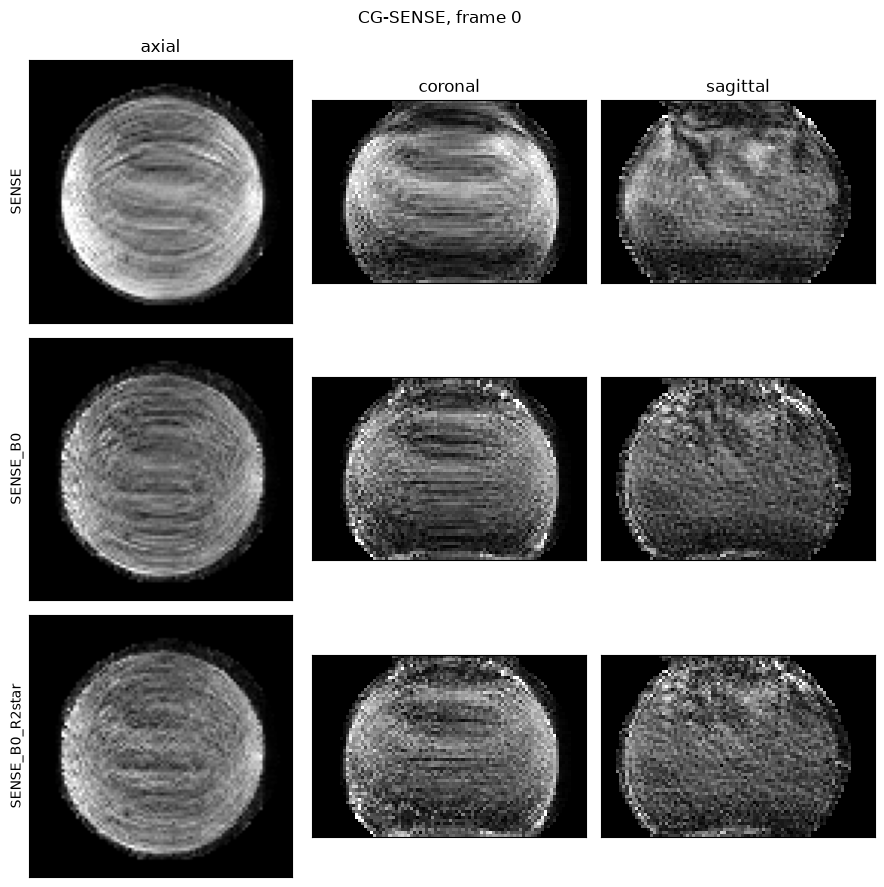

In [8]:
res_cg = recon_three_ways("none", frames=[0, 1], niters=20)
show({k: r.X_recon for k, r in res_cg.items()}, title="CG-SENSE, frame 0")

### 4b. Multi-scale low-rank: POGM

`reg="lowrank"`: each `(patch, stride)` pair is one scale. The image is written
as $X = \sum_k X_k$, and each component is penalized by the nuclear norm of its
space × time patches:

* one local patch size gives the locally low-rank (LLR) prior
* adding a whole-volume patch gives the global + local (G+L) decomposition

The λ for each scale comes from the Ong & Lustig closed form, times
`lambda_global` (default R). Solved with POGM; set `mom` to `"fpgm"` or `"pgm"`
for the other variants. Low-rank needs several frames, so this uses 10 frames and
10 iterations (the CLI default is 200, with early stopping).

Loading sensitivity maps...


  Sensitivity maps: (90, 90, 60, 14)
Acceleration factor R ~ 6.00
Building encoding operator...
  sigma1A not supplied -- measuring via power iteration...


    sigma1A = 0.999817
Loading k-space (gathered per frame, never materializing the dense array)...


  VRAM free after loading gathered k-space: 48.87 / 50.90 GB


  Operator noise-propagation factor = 0.4084 -- rescaling ksp/X0 by 1/0.4084
Regularization weights lambdas = [126.149131]
Initializing X0...


...

    sigma1A = 1.887099
Loading k-space (gathered per frame, never materializing the dense array)...


  VRAM free after loading gathered k-space: 48.30 / 50.90 GB


  Operator noise-propagation factor = 0.4291 -- rescaling ksp/X0 by 1/0.4291
Regularization weights lambdas = [126.149131]
Initializing X0...



Iteratively reconstructing (10 iterations, 1 scale(s), mom=pogm, conv_tol=1e-05)...


Wall-clock: 90.7 s, 9.07 s/iter
==> SENSE_B0_R2star: 160.7 s


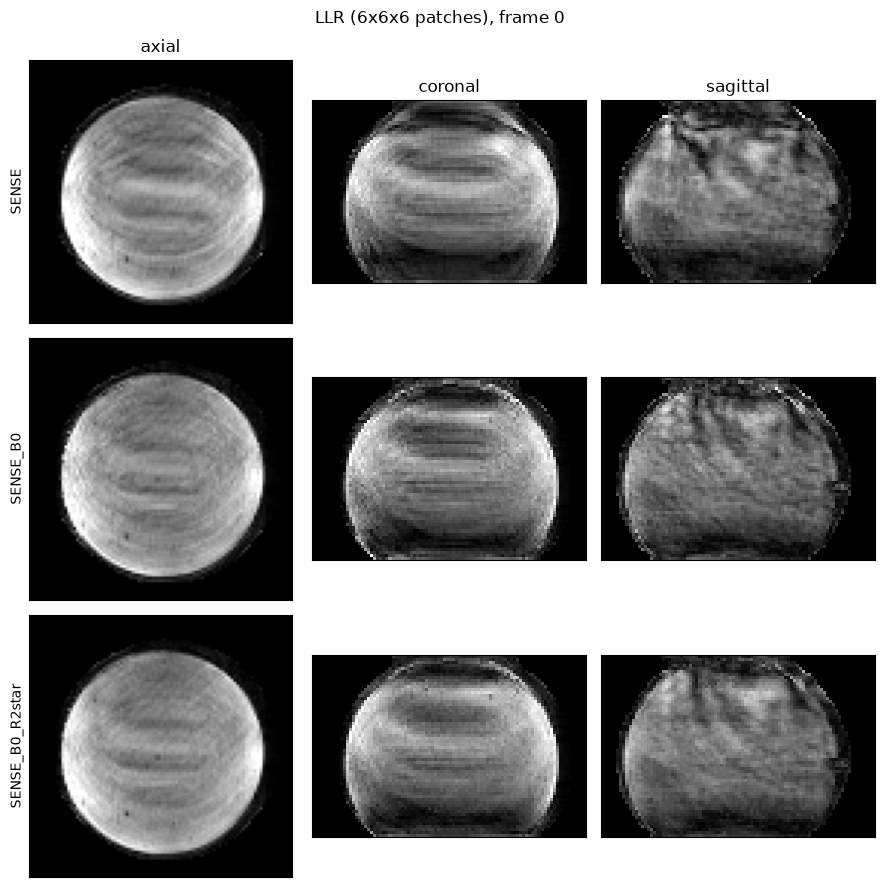

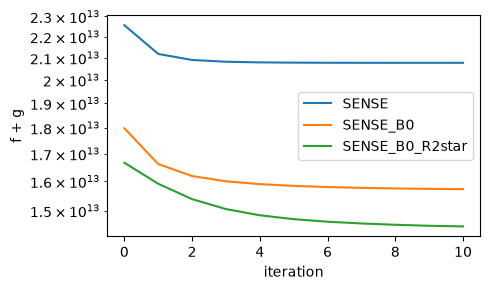

In [9]:
res_lr = recon_three_ways(
    "lowrank", frames=list(range(10)), niters=10,
    patch_sizes=[(6, 6, 6)], strides=[(3, 3, 3)], lambda_global=None, mom="pogm",
)
show({k: r.X_recon for k, r in res_lr.items()}, title="LLR (6x6x6 patches), frame 0")

plt.figure(figsize=(5, 3))
for k, r in res_lr.items():
    plt.semilogy(np.array(r.dc_costs) + np.array(r.reg_costs), label=k)
plt.xlabel("iteration")
plt.ylabel("f + g")
plt.legend()
plt.tight_layout()
plt.show()

### 4c. L1-wavelet + TV: FBPD

`reg="wavelet-tv"`: $g(x) = \lambda_{\ell_1}\|Wx\|_1 + \lambda_{TV}\|Dx\|_1$, with
an orthogonal 3D wavelet $W$ and finite differences $D$. TV has no closed-form
prox, so this is solved per frame with mirtorch's primal-dual FBPD instead of
POGM. The operator is normalized to unit spectral norm and the data to O(1),
so the default λ = 0.005 carries over between datasets. Runs frame 0 for 50
iterations (the CLI default is 100).

Loading sensitivity maps...
  Sensitivity maps: (90, 90, 60, 14)
Acceleration factor R ~ 6.00
Building encoding operator...
  sigma1A not supplied -- measuring via power iteration...


    sigma1A = 0.999815
Loading k-space (gathered per frame, never materializing the dense array)...
  VRAM free after loading gathered k-space: 48.31 / 50.90 GB

Reconstructing 1 frame(s) with L1-wavelet + TV (lamb_l1=0.005, lamb_tv=0.005, 50 FBPD iterations, operator normalized by 1/0.9998)...


  frame 1/1 done in 0.5s
Wall-clock: 0.5s (0.5s/frame)
==> SENSE: 1.5 s
Loading sensitivity maps...
  Sensitivity maps: (90, 90, 60, 14)
Acceleration factor R ~ 6.00
Building encoding operator...
  Loading B0 field map from /StorageRAID/rexfung/20260915ball/recon/2_6x_2.4mm_b0map.h5 (L=32, nbins=128)...
  sigma1A not supplied -- measuring via power iteration...


    sigma1A = 1.198171
Loading k-space (gathered per frame, never materializing the dense array)...
  VRAM free after loading gathered k-space: 48.31 / 50.90 GB

Reconstructing 1 frame(s) with L1-wavelet + TV (lamb_l1=0.005, lamb_tv=0.005, 50 FBPD iterations, operator normalized by 1/1.1982)...


  frame 1/1 done in 7.3s
Wall-clock: 7.3s (7.3s/frame)
==> SENSE_B0: 35.6 s
Loading sensitivity maps...
  Sensitivity maps: (90, 90, 60, 14)
Acceleration factor R ~ 6.00
Building encoding operator...
  Loading B0 field map from /StorageRAID/rexfung/20260915ball/recon/2_6x_2.4mm_b0map.h5 (L=32, nbins=128)...
  R2* correction enabled (t_ref_s=29.651 ms)...
  build_sense_b0_r2star: R2* decay-time product = 5.3424 vs Δf's bandwidth-time product = 9.21 (should be much smaller -- this is what justifies reusing Δf-only-tuned b_by_echo/tl for the complex field; see module docstring).
  sigma1A not supplied -- measuring via power iteration...


    sigma1A = 1.863753
Loading k-space (gathered per frame, never materializing the dense array)...
  VRAM free after loading gathered k-space: 48.31 / 50.90 GB

Reconstructing 1 frame(s) with L1-wavelet + TV (lamb_l1=0.005, lamb_tv=0.005, 50 FBPD iterations, operator normalized by 1/1.8638)...


  frame 1/1 done in 7.3s
Wall-clock: 7.3s (7.3s/frame)
==> SENSE_B0_R2star: 10.9 s


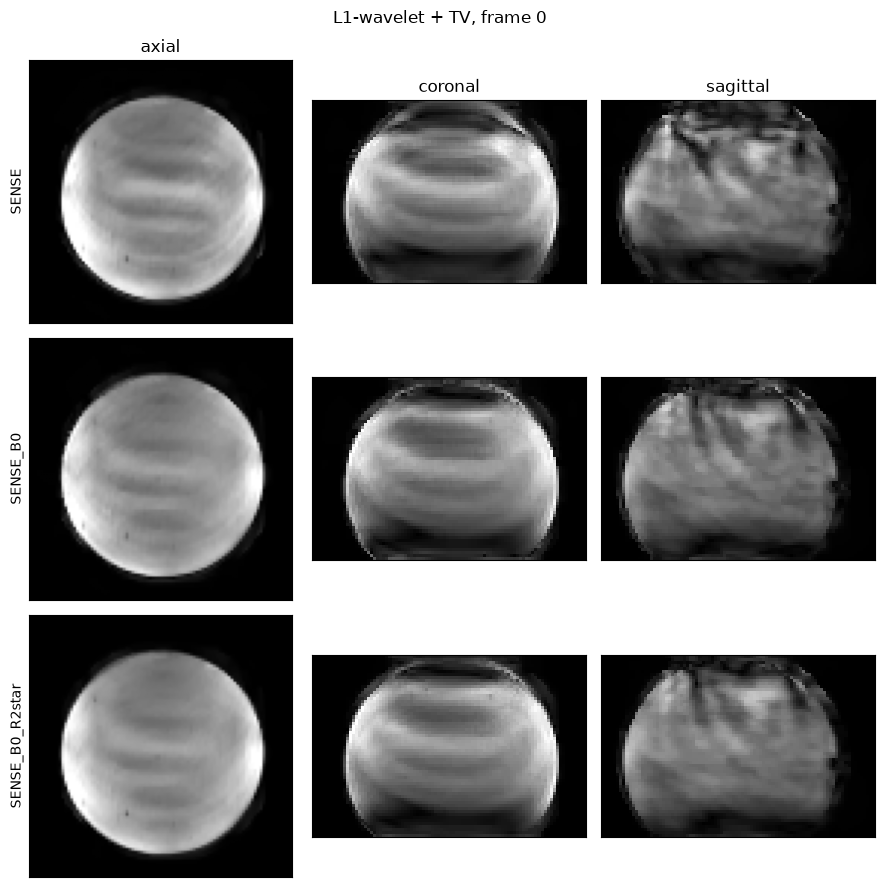

In [10]:
res_wt = recon_three_ways("wavelet-tv", frames=[0], niters=50, lamb_l1=0.005, lamb_tv=0.005)
show({k: r.X_recon for k, r in res_wt.items()}, title="L1-wavelet + TV, frame 0")

## 5. Side by side

Frame 0 from each method, all with the B0 + R2* operator (RSS has no operator).

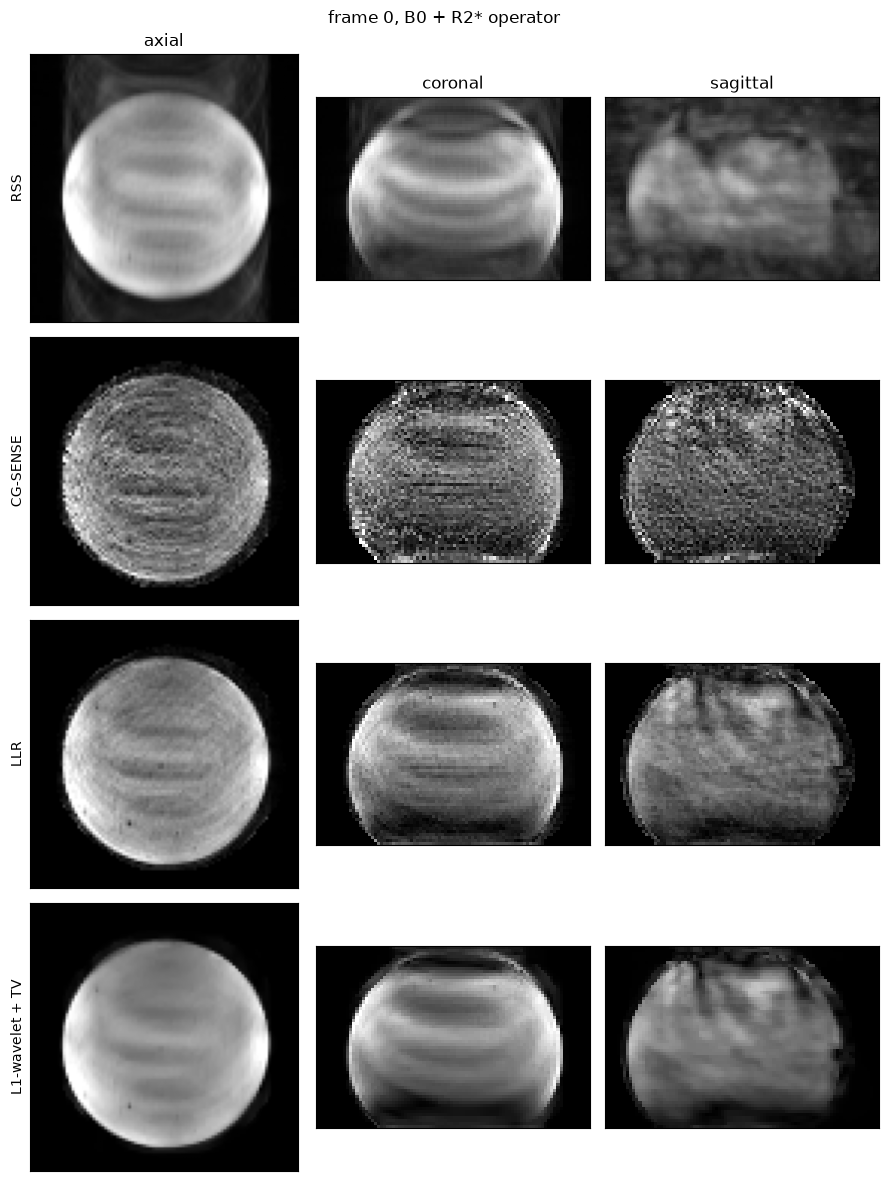

In [11]:
show({
    "RSS": img_rss,
    "CG-SENSE": res_cg["SENSE_B0_R2star"].X_recon,
    "LLR": res_lr["SENSE_B0_R2star"].X_recon,
    "L1-wavelet + TV": res_wt["SENSE_B0_R2star"].X_recon,
}, title="frame 0, B0 + R2* operator")

## 6. Temporal stability (`recon/utils.py`)

`tsnr_report` takes saved `.nii.gz` reconstructions and reports percent
fluctuation, drift, and tSNR, and saves a figure. Here it runs on the RSS
series, saved to a temporary directory.


=== rss ===
  object mask: 157761 voxels (32.5% of volume)
  percent fluctuation (detrended): 4.861%
  percent drift (linear, over 59s): -4.238%
  ROI tSNR (undetrended): 19.9
  median per-voxel tSNR: 7.7


Wrote /tmp/user/1015/tmp62hqppjf/rss_tsnr.png


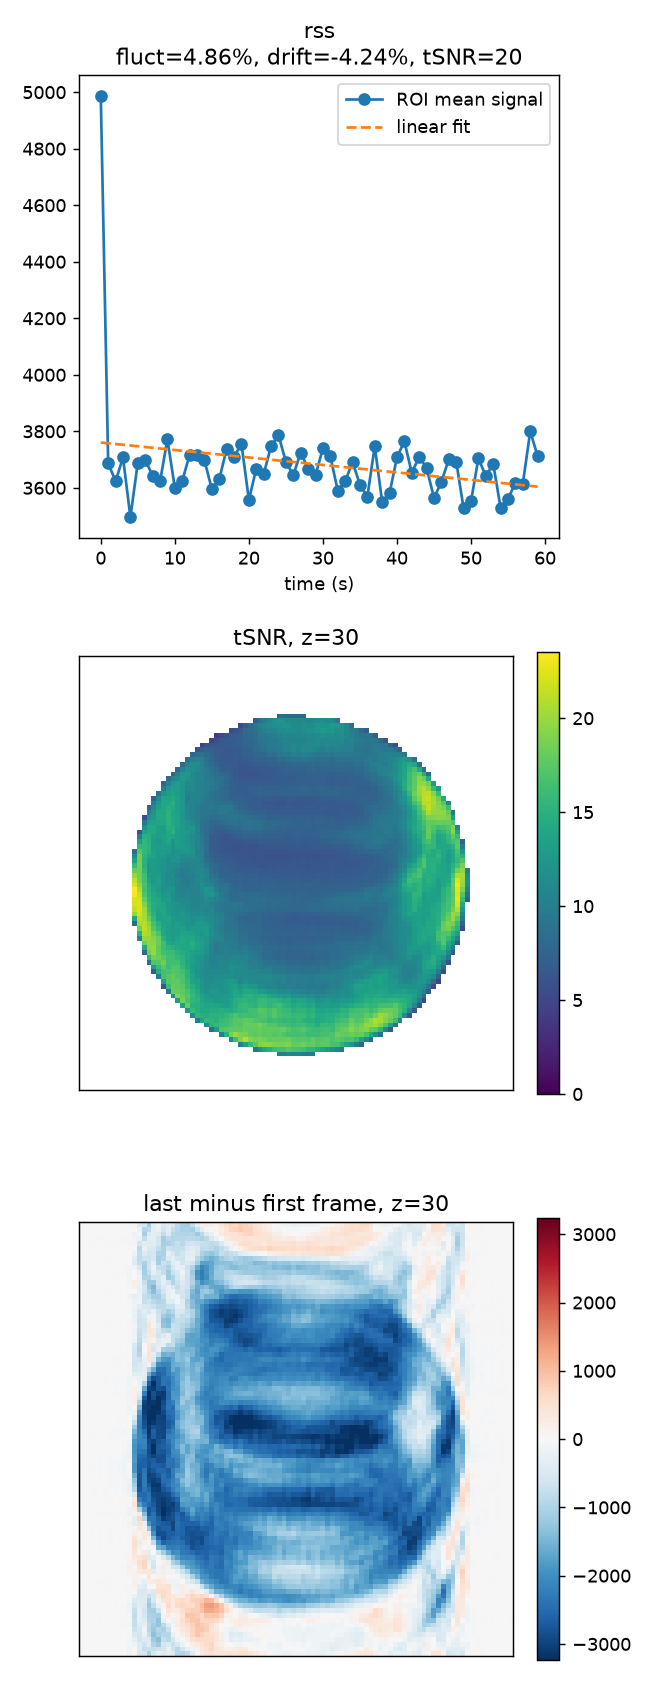

In [12]:
import tempfile

from IPython.display import Image

from preprocessing.nifti_io import save_recon_nifti
from recon.utils import tsnr_report

out = Path(tempfile.mkdtemp())
save_recon_nifti(str(out / "rss"), img_rss, fov=sp.fov, seqname=SEQ)
stats = tsnr_report([str(out / "rss.nii.gz")], tr_s=sp.volume_tr)
Image(str(out / "rss_tsnr.png"), width=400)

## 7. Command line

Each call above has a command-line equivalent that writes
`<datdir>/recon/<method>/<seq>_recon.{h5,nii.gz,json}`. With `--frames`, the
filename gets a `_frames...` suffix.

```bash
PY=.venv-recon/bin/python
$PY -m recon.rss   $DATDIR 2_6x_2.4mm
$PY -m recon.sense $DATDIR 2_6x_2.4mm --reg none       --B0 --R2star
$PY -m recon.sense $DATDIR 2_6x_2.4mm --reg lowrank    --B0 --patch 6 6 6 --stride 3 3 3
$PY -m recon.sense $DATDIR 2_6x_2.4mm --reg lowrank    --B0 --patch full --patch 15 15 15 --stride full --stride 5 5 5   # G+L
$PY -m recon.sense $DATDIR 2_6x_2.4mm --reg wavelet-tv --B0 --frames 0-9
$PY -m recon.utils tsnr $DATDIR/recon/rss/2_6x_2.4mm_recon.nii.gz --tr 1.0
```